```
conda activate sdxl
torch-model-archiver --model-name sdxl --version 1.0 --handler handler.py --export-path model_store -f
torchserve --stop
TS_INFERENCE_ADDRESS=http://0.0.0.0:8080 TS_MANAGEMENT_ADDRESS=http://0.0.0.0:8081 torchserve --start --ncs --model-store model_store --models sdxl=sdxl.mar --ts-config config.properties --disable-token-auth


# seed를 42(또는 아무 숫자)로 고정하여 요청
$jsonPayload = '{"prompt": "A majestic dragon...", "seed": 42}'

curl.exe -X POST "http://34.64.206.210:8080/predictions/sdxl" `
     -H "Content-Type: application/json" `
     -d $jsonPayload `
     --output "seed_test_1.png"
```

In [3]:
import os
import sys
import logging
import pandas as pd
import requests
import requests
import base64
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
from helper_dev_utils import get_auto_logger, set_pandas_extension
from helper_plot_hangul import matplotlib_font_reset

logger = get_auto_logger(log_level=logging.DEBUG)


In [4]:

def generate_image(prompt=None, image_path=None, strength=0.75, seed=None):
    """
    세 가지 모드 지원:
    1. prompt만: Text-to-Image
    2. image_path만: Image-to-Image (유사 이미지)
    3. prompt + image_path: Image-to-Image (텍스트 기반 변경)
    
    Args:
        seed (int, optional): 재현 가능한 이미지 생성을 위한 시드값
    """
    url = "http://34.64.206.210:8080/predictions/sdxl"
    
    payload = {}
    
    if prompt:
        payload["prompt"] = prompt
    
    if image_path:
        with open(image_path, 'rb') as f:
            image_b64 = base64.b64encode(f.read()).decode('utf-8')
            payload["image"] = image_b64
    
    payload["strength"] = strength
    
    if seed is not None:
        payload["seed"] = seed
    
    headers = {"Content-Type": "application/json"}
    
    try:
        response = requests.post(url, json=payload, headers=headers)
        response.raise_for_status()
        
        image = Image.open(BytesIO(response.content))
        logger.info(f"이미지 생성 성공: prompt={prompt}, image={image_path}, seed={seed}")
        return image
    except Exception as e:
        logger.error(f"API 호출 실패: {e}")
        return None


2025-12-24 21:54:17 I [ipykernel_launcher:35] - 이미지 생성 성공: prompt=A majestic dragon, image=None, seed=100


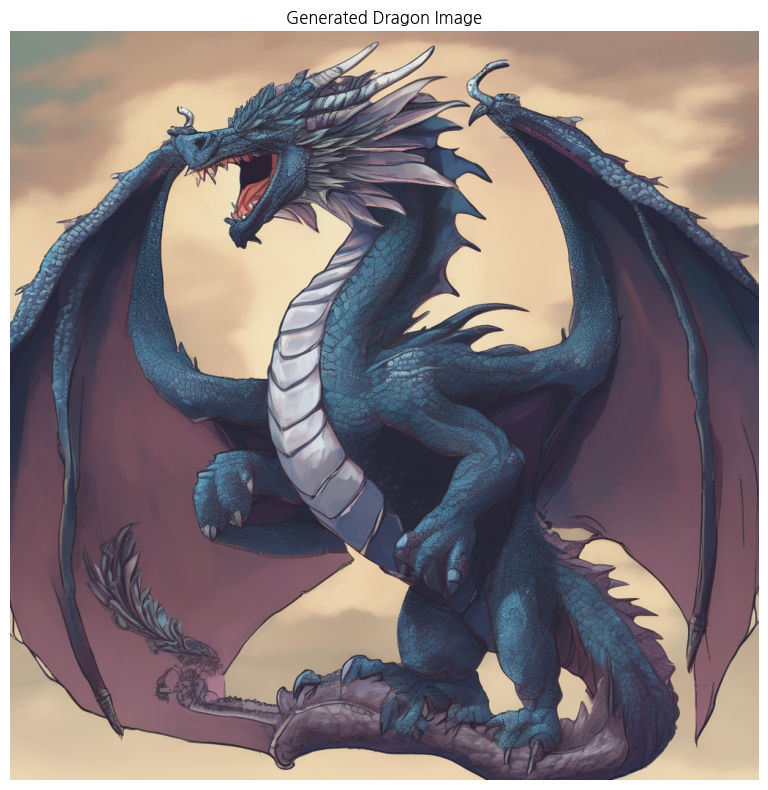

In [5]:
image1 = generate_image(prompt="A majestic dragon",  seed=100)
if image1:
    plt.figure(figsize=(10, 8))
    plt.imshow(image1)
    plt.axis('off')
    plt.title("Generated Dragon Image")
    plt.tight_layout()
    plt.show()
    
if image1:
    image1.save("dragon.png")


2025-12-24 21:54:28 I [ipykernel_launcher:35] - 이미지 생성 성공: prompt=None, image=dragon.png, seed=None


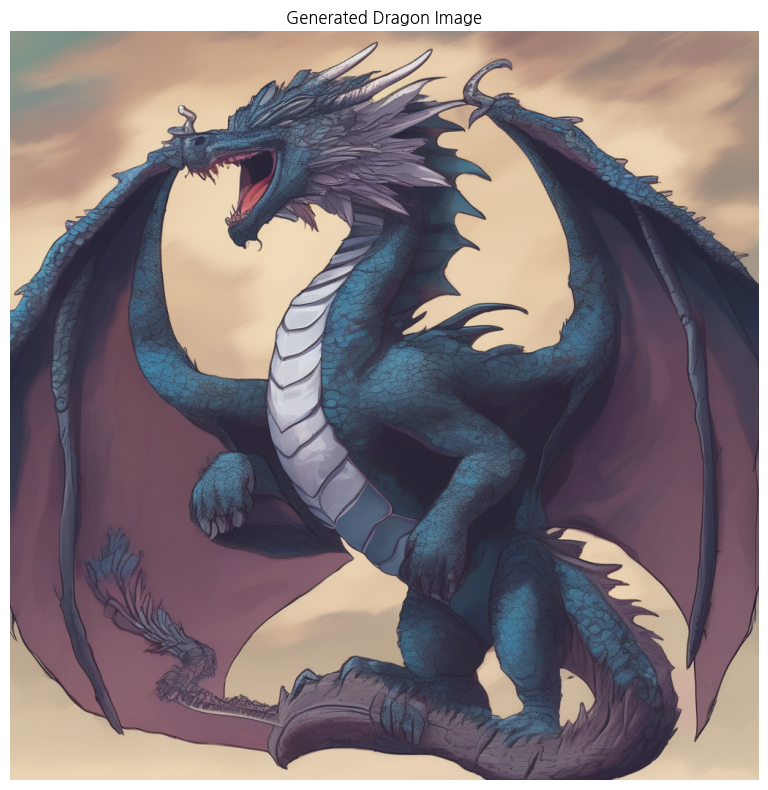

In [6]:
image2 = generate_image(image_path="dragon.png", strength=0.3)
if image2:
    plt.figure(figsize=(10, 8))
    plt.imshow(image2)
    plt.axis('off')
    plt.title("Generated Dragon Image")
    plt.tight_layout()
    plt.show()


2025-12-24 21:54:47 I [ipykernel_launcher:35] - 이미지 생성 성공: prompt=A majestic dragon flying over ocean with sea waves, image=dragon.png, seed=None


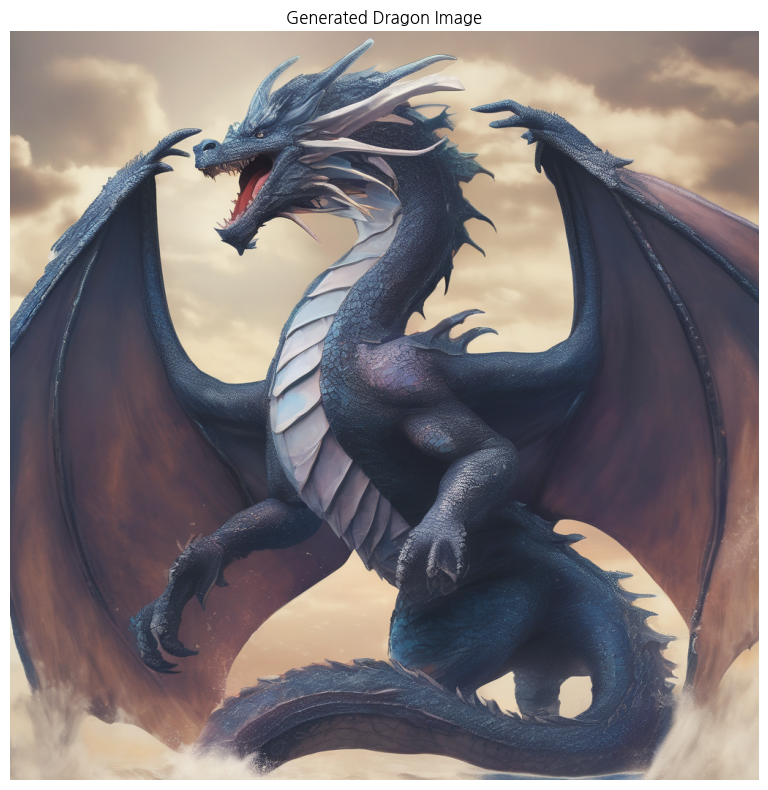

In [7]:
image3 = generate_image(
    prompt="A majestic dragon flying over ocean with sea waves",
    image_path="dragon.png",
    strength=0.75
)
if image3:
    plt.figure(figsize=(10, 8))
    plt.imshow(image3)
    plt.axis('off')
    plt.title("Generated Dragon Image")
    plt.tight_layout()
    plt.show()
